<a href="https://colab.research.google.com/github/ekyaaa/pengolahan-citra/blob/main/Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11


# Preparation

In [8]:
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, clear_output
from IPython.display import Image as IPImage
from numpy.lib.stride_tricks import as_strided
from scipy.signal import fftconvolve
from skimage.feature import peak_local_max

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Practicum

## **PRACTICUM-1: Basic Object Detection**

### 1. Implement **Template Matching**

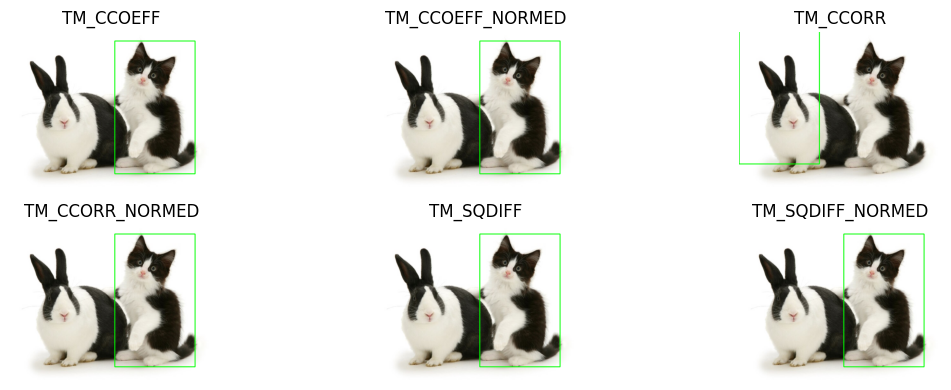

In [10]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/Object Detection/cat-and-rabbit.jpg')
template = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/Object Detection/cat-template.jpg')

if img is None or template is None:
    raise Exception('Image is nout found!')

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)


match_template_methods = [
    ("TM_CCOEFF", cv2.TM_CCOEFF),
    ("TM_CCOEFF_NORMED", cv2.TM_CCOEFF_NORMED),
    ("TM_CCORR", cv2.TM_CCORR),
    ("TM_CCORR_NORMED", cv2.TM_CCORR_NORMED),
    ("TM_SQDIFF", cv2.TM_SQDIFF),
    ("TM_SQDIFF_NORMED", cv2.TM_SQDIFF_NORMED),
]



# Result visualization
# Create subplots: 2 row, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(12, 4))
axes = axes.ravel()

# Loop through each subplot
for ax, (method_name, method) in zip(axes, match_template_methods):
    result = cv2.matchTemplate(img_gray, template_gray, method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    h, w = template_gray.shape
    bottom_right = (top_left[0] + w, top_left[1] + h)

    img_display = img.copy()
    cv2.rectangle(img_display, top_left, bottom_right, (0, 255, 0), 2)

    ax.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
    ax.set_title(method_name)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 2. Implement **Template Matching** from Scratch for Multiple Objects

In [11]:
def rgb2gray(img: np.ndarray) -> np.ndarray:
    """
    Convert an RGB image to grayscale using NumPy.
    Formula: Gray = 0.2989*R + 0.5870*G + 0.1140*B
    """
    if img.ndim == 3 and img.shape[2] == 3:
        return np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])
    elif img.ndim == 2:
        return img  # already grayscale
    else:
        raise ValueError("Input image must have 3 channels (RGB)")

def fast_template_match(
    img_gray: np.ndarray,
    template_gray: np.ndarray
) -> np.ndarray:
    H, W = img_gray.shape
    h, w = template_gray.shape

    N = h * w
    template = (template_gray - template_gray.mean()).ravel()

    # Create strided view of all (h×w) patches
    shape = (H - h + 1, W - w + 1, h, w)
    strides = img_gray.strides * 2
    patches = as_strided(img_gray, shape=shape, strides=strides)
    patches_2d = patches.reshape(-1, N)

    # Normalize patches
    patches_2d = (patches_2d - patches_2d.mean(axis=1, keepdims=True))
    denom = np.linalg.norm(patches_2d, axis=1) * np.linalg.norm(template)
    denom[denom == 0] = 1e-5

    result = (patches_2d @ template) / denom
    return result.reshape(H - h + 1, W - w + 1)

def fast_template_match_fft(
    img_gray: np.ndarray,
    template_gray: np.ndarray
) -> np.ndarray:
    h, w = template_gray.shape

    # Normalize template
    template = (template_gray - np.mean(template_gray))
    template_std = np.std(template_gray)

    # Compute cross-correlation using FFT
    corr = fftconvolve(img_gray, template[::-1, ::-1], mode='valid')

    # Compute mean and std in image windows
    ones = np.ones_like(template)
    local_sum = fftconvolve(img_gray, ones, mode='valid')
    local_sum_sq = fftconvolve(img_gray**2, ones, mode='valid')

    N = h * w
    mean_I = local_sum / N
    std_I = np.sqrt(np.maximum(local_sum_sq / N - mean_I**2, 1e-6))

    # Normalize correlation to get NCC
    result = (corr - mean_I * np.sum(template)) / (std_I * template_std * N)
    return result


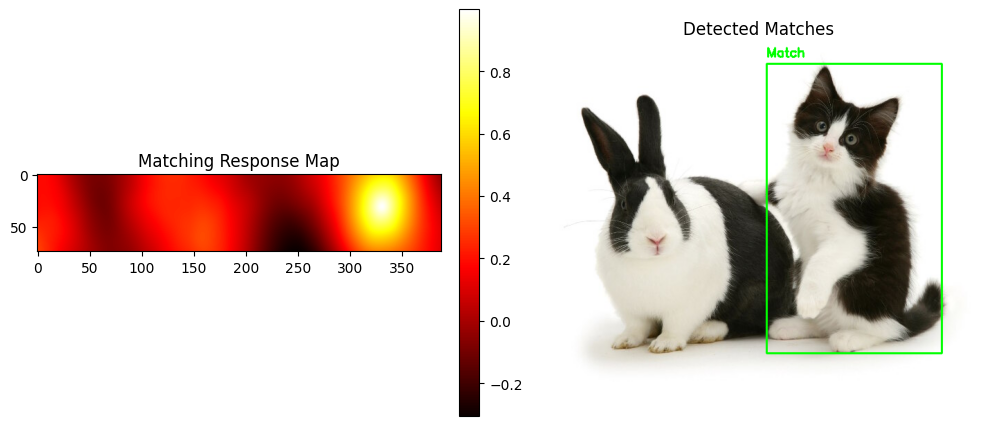

In [12]:
# Load image and template
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/Object Detection/cat-and-rabbit.jpg')
template = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/Object Detection/cat-template.jpg')

if img is None or template is None:
    raise Exception('Images is not found!')

# Convert to grayscale
img_gray = rgb2gray(img)
template_gray = rgb2gray(template)

result = fast_template_match_fft(img_gray, template_gray)

# Detect top matches (peaks in response map)
coordinates = peak_local_max(result, min_distance=20, threshold_abs=0.6)

# Draw bounding boxes on the original image
h, w = template_gray.shape
img_display = img.copy()

for (y, x) in coordinates:
    top_left = (x, y)
    bottom_right = (x + w, y + h)
    cv2.rectangle(img_display, top_left, bottom_right, (0, 255, 0), 2)
    cv2.putText(img_display, "Match", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Convert to RGB for Matplotlib
img_rgb = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)

# Show results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(result, cmap='hot')
plt.title("Matching Response Map")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 2, 2)
plt.imshow(img_rgb)
plt.title("Detected Matches")
plt.axis('off')

plt.tight_layout()
plt.show()

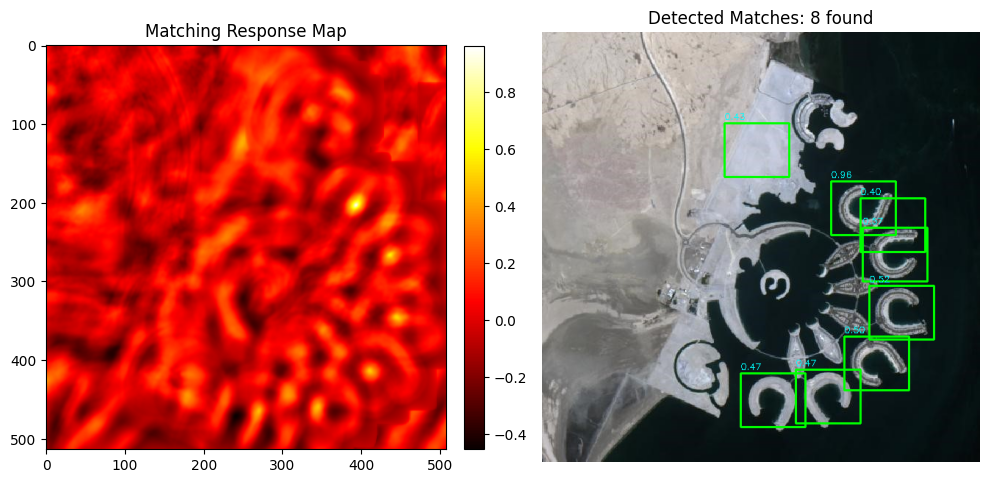

In [13]:
# Load image and template
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/Object Detection/bahrain.jpg')
template = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/Object Detection/bahrain-template.jpg')

if img is None or template is None:
    raise Exception('Images is not found!')

# Convert to grayscale
img_gray = rgb2gray(img)
template_gray = rgb2gray(template)

result = fast_template_match_fft(img_gray, template_gray)

# Automatically pick threshold based on best correlation
threshold_abs = result.max() * 0.4  # 40% of best score
coordinates = peak_local_max(result, min_distance=5, threshold_abs=threshold_abs)

# Draw bounding boxes
h, w = template_gray.shape
img_display = img.copy()

for (y, x) in coordinates:
    top_left = (x, y)
    bottom_right = (x + w, y + h)
    cv2.rectangle(img_display, top_left, bottom_right, (0, 255, 0), 2)
    cv2.putText(img_display, f"{result[y,x]:.2f}", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)

# Convert to RGB for Matplotlib
img_rgb = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)

# Display results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(result, cmap='hot')
plt.title("Matching Response Map")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 2, 2)
plt.imshow(img_rgb)
plt.title(f"Detected Matches: {len(coordinates)} found")
plt.axis('off')

plt.tight_layout()
plt.show()

### 3. Implement **Sobel Edge Detection, Canny Edge Detection, and Laplacian Edge Detection** with OpenCV

#### 3.1 Sobel Edge Detection

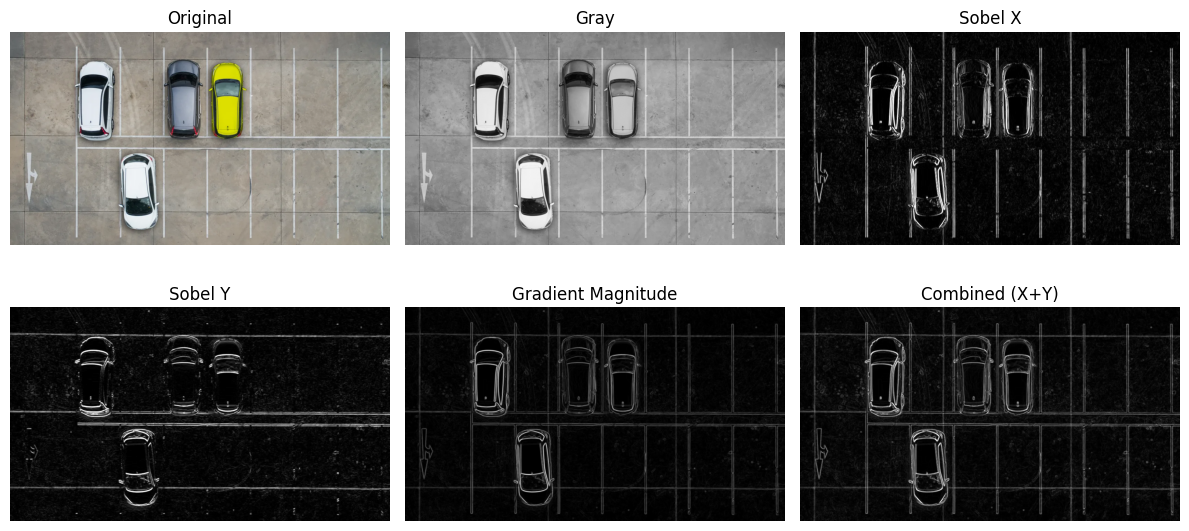

In [14]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/Object Detection/car-park.jpg')

if img is None:
    raise Exception('Image is not found!')

# Convert to grayscale and smooth to reduce noise
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.GaussianBlur(gray, (3, 3), 0)

# Compute Sobel derivatives (float64)
sobelx_f = cv2.Sobel(gray_blur, cv2.CV_64F, 1, 0, ksize=3)
sobely_f = cv2.Sobel(gray_blur, cv2.CV_64F, 0, 1, ksize=3)

# Convert to 8-bit images for visualization (absolute)
sobelx = cv2.convertScaleAbs(sobelx_f)
sobely = cv2.convertScaleAbs(sobely_f)

# Gradient magnitude (normalized to 0-255)
magnitude = np.sqrt(sobelx_f**2 + sobely_f**2)
magnitude = (255 * (magnitude / (magnitude.max() + 1e-8))).astype(np.uint8)

# Simple combined visualization
combined = cv2.addWeighted(sobelx, 0.5, sobely, 0.5, 0)

# Prepare data for plotting
plots = [
    ('Original', cv2.cvtColor(img, cv2.COLOR_BGR2RGB)),
    ('Gray', gray),
    ('Sobel X', sobelx),
    ('Sobel Y', sobely),
    ('Gradient Magnitude', magnitude),
    ('Combined (X+Y)', combined),
]

# Create subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

# Loop through subplots and images
for ax, (title, img_data) in zip(axes, plots):
    if len(img_data.shape) == 2:  # Grayscale image
        ax.imshow(img_data, cmap='gray')
    else:  # Color image
        ax.imshow(img_data)

    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

#### 3.2 Canny Edge Detection

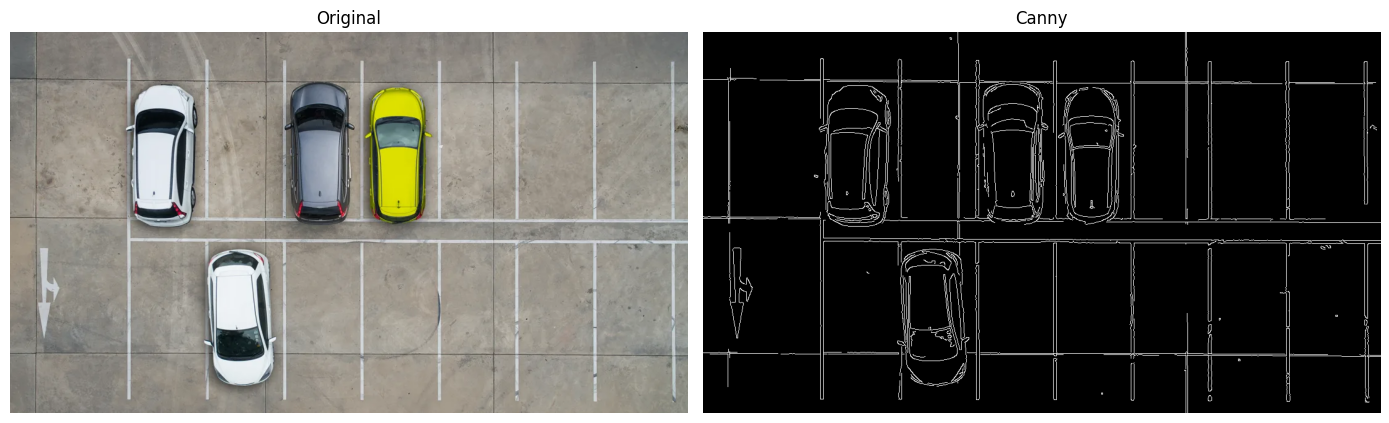

In [15]:
canny = cv2.Canny(gray_blur, threshold1=100, threshold2=200)

# Add new experiments to plots
plots = [
    ('Original', cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), # type: ignore
    ('Canny', canny),
]

# Adjust figure layout (e.g. 1 rows, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes = axes.ravel()

for ax, (title, img_data) in zip(axes, plots):
    if len(img_data.shape) == 2:
        ax.imshow(img_data, cmap='gray')
    else:
        ax.imshow(img_data)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

#### 3.3 Laplacian Edge Detection

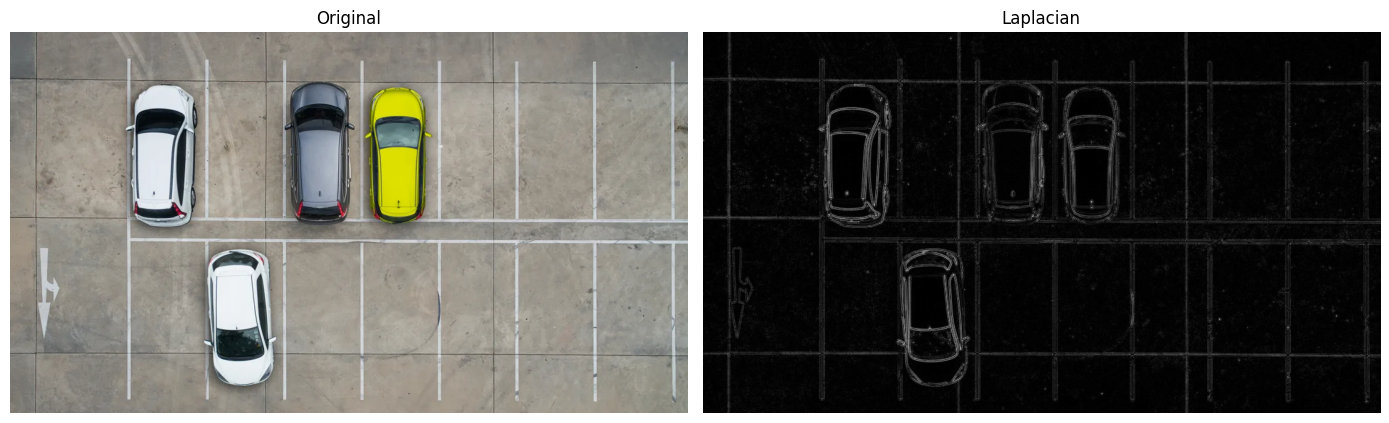

In [16]:
# Laplacian edge detection (float64)
laplacian_f = cv2.Laplacian(gray_blur, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian_f)

# Add new experiments to plots
plots = [
    ('Original', cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), # type: ignore
    ('Laplacian', laplacian),
]

# Adjust figure layout (e.g. 1 rows, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes = axes.ravel()

for ax, (title, img_data) in zip(axes, plots):
    if len(img_data.shape) == 2:
        ax.imshow(img_data, cmap='gray')
    else:
        ax.imshow(img_data)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 4. Implement **Harris Corner and Shi-Tomasi Detection** with OpenCV

#### 4.1 Harris Corner Detection

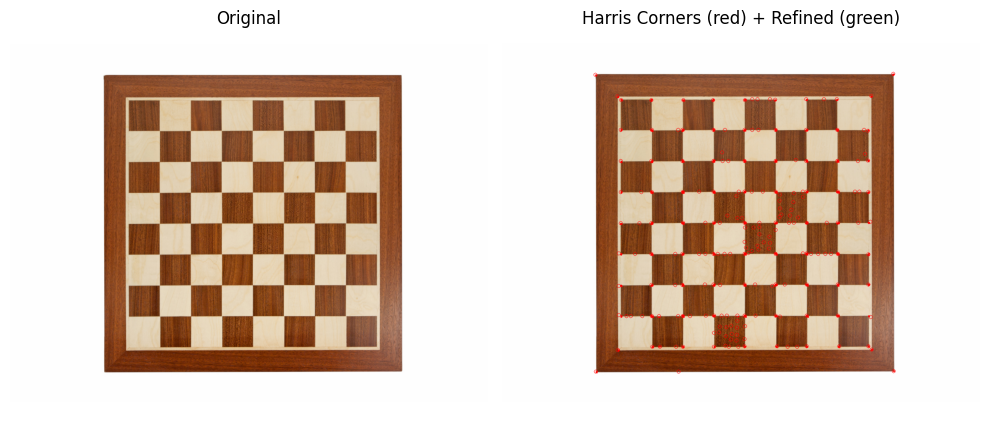

In [17]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/Object Detection/chess-board.jpg')

if img is None:
    raise Exception('Image is not found!')

# Convert to grayscale and to float32 for Harris
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_f = np.float32(gray)

# Harris corner detector
dst = cv2.cornerHarris(gray_f, blockSize=2, ksize=3, k=0.04) # type: ignore

# Dilate result to mark the corners
dst_dilated = cv2.dilate(dst, None) # type: ignore

# Create copy for visualization and mark detected corners in red (BGR)
img_harris = img.copy()
threshold = 0.01 * dst_dilated.max()
img_harris[dst_dilated > threshold] = [0, 0, 255]

# Optional: refine corners to sub-pixel accuracy using goodFeaturesToTrack + cornerSubPix
corners = cv2.goodFeaturesToTrack(gray, maxCorners=200, qualityLevel=0.01, minDistance=8)
if corners is not None:
    corners = np.float32(corners)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 40, 0.001)
    cv2.cornerSubPix(gray, corners, winSize=(5,5), zeroZone=(-1,-1), criteria=criteria) # type: ignore
    for c in corners: # type: ignore
        x, y = c.ravel()
        cv2.circle(img_harris, (int(x), int(y)), 4, (0, 0, 255), 1)  # refined corners in red

# Plot original and Harris result
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_harris, cv2.COLOR_BGR2RGB))
axes[1].set_title('Harris Corners (red) + Refined (green)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### 4.2 Shi-Tomasi Detection

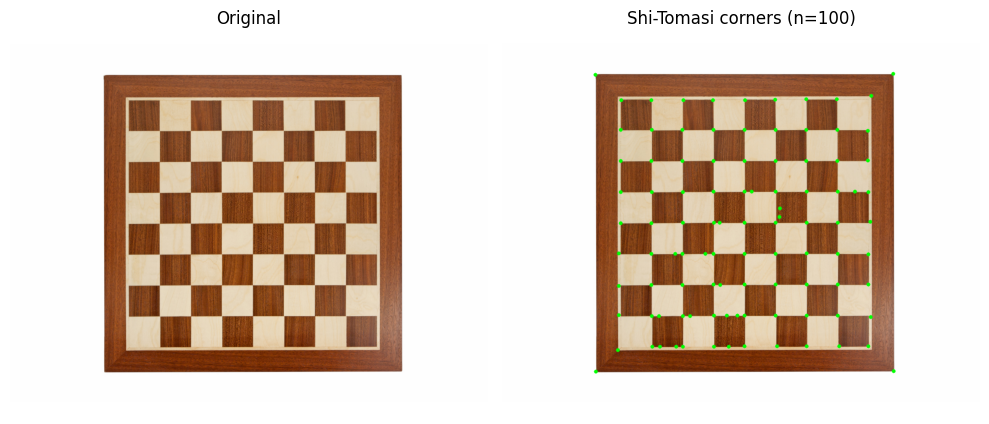

In [18]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/Object Detection/chess-board.jpg')

if img is None:
    raise Exception('Image is not found!')

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Shi-Tomasi (Good Features to Track) parameters
max_corners = 100
quality_level = 0.01
min_distance = 10
block_size = 3
use_harris = False

corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=max_corners,
    qualityLevel=quality_level,
    minDistance=min_distance,
    blockSize=block_size,
    useHarrisDetector=use_harris
)

# Optional: refine to sub-pixel accuracy
if corners is not None:
    corners = np.float32(corners)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 40, 0.001)
    cv2.cornerSubPix(gray, corners, winSize=(5,5), zeroZone=(-1,-1), criteria=criteria) # type: ignore

# Draw detected corners
img_st = img.copy()
if corners is not None:
    for c in corners: # type: ignore
        x, y = c.ravel()
        cv2.circle(img_st, (int(x), int(y)), 4, (0, 255, 0), -1)

# Display original and result
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_st, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Shi-Tomasi corners (n={0 if corners is None else len(corners)})') # type: ignore
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 5. Implement **Hough Transform** with OpenCV

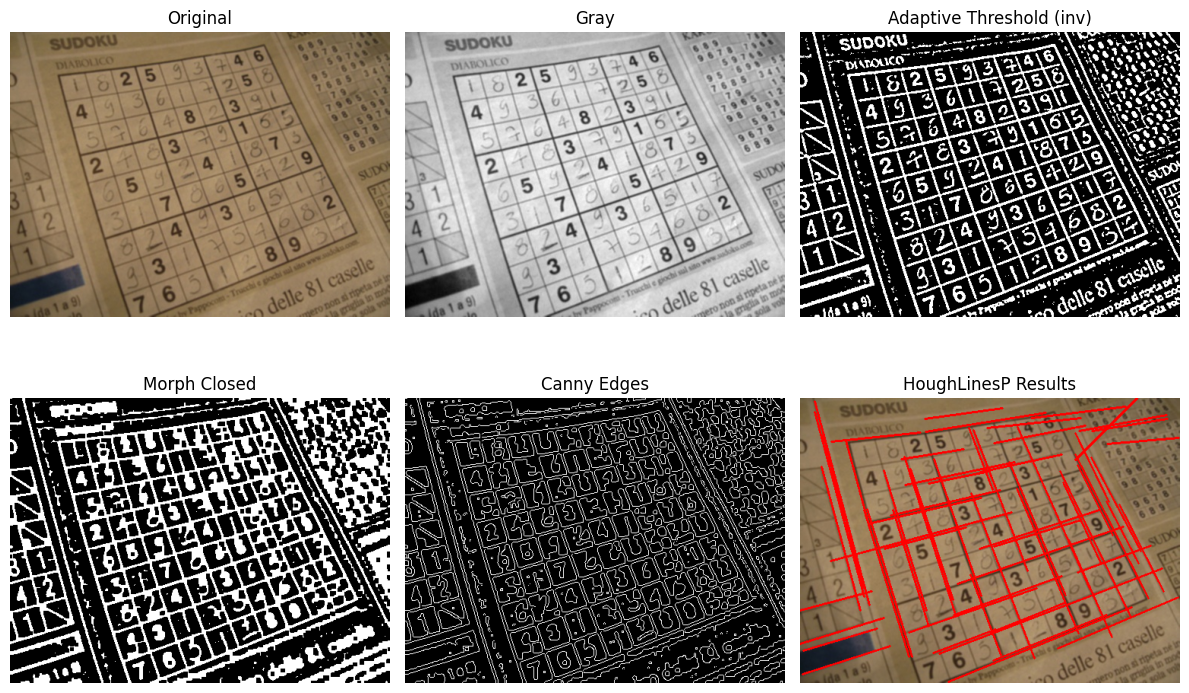

In [19]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/Object Detection/sudoku.jpg')

if img is None:
    raise Exception('Image is not found!')

# Prepare grayscale / enhance grid
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
thresh = cv2.adaptiveThreshold(blur, 255,
                               cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY_INV, 11, 2)

# Morphological closing to strengthen grid lines
kernel = np.ones((3, 3), np.uint8)
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

# Edge detection
edges = cv2.Canny(closed, 50, 150, apertureSize=3)

# Probabilistic Hough Line Transform
lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180,
                        threshold=100, minLineLength=80, maxLineGap=10)

# Draw detected lines
img_lines = img.copy()
if lines is not None:
    for x1, y1, x2, y2 in lines[:, 0]:
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Optional: draw extended lines using HoughLines (standard) for visualization
# hl = cv2.HoughLines(edges, 1, np.pi/180, 150)
# if hl is not None:
#     for rho,theta in hl[:,0]:
#         a = np.cos(theta); b = np.sin(theta)
#         x0 = a*rho; y0 = b*rho
#         pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
#         pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
#         cv2.line(img_lines, pt1, pt2, (0,255,0), 1)

# Show results
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Gray')
axes[1].axis('off')

axes[2].imshow(thresh, cmap='gray')
axes[2].set_title('Adaptive Threshold (inv)')
axes[2].axis('off')

axes[3].imshow(closed, cmap='gray')
axes[3].set_title('Morph Closed')
axes[3].axis('off')

axes[4].imshow(edges, cmap='gray')
axes[4].set_title('Canny Edges')
axes[4].axis('off')

axes[5].imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
axes[5].set_title('HoughLinesP Results')
axes[5].axis('off')

plt.tight_layout()
plt.show()

### 6. Implement Function **findContours()** for Countour Detection

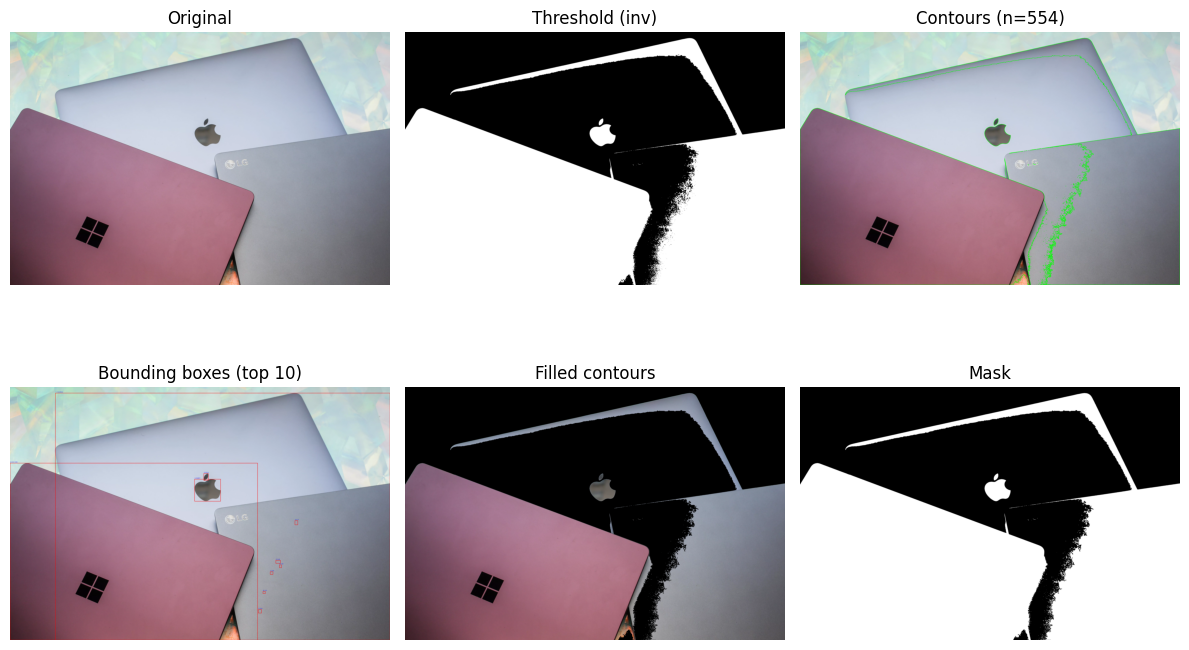

In [20]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/Object Detection/laptop.jpg')

if img is None:
    raise Exception('Image is not found!')

# Preprocess
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Binary threshold (Otsu) and invert so objects are white
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
thresh_inv = 255 - thresh

# Find contours (robust to OpenCV version)
cnts_info = cv2.findContours(thresh_inv.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = cnts_info[0] if len(cnts_info) == 2 else cnts_info[1]
contours = sorted(contours, key=cv2.contourArea, reverse=True)

# Draw all contours
img_contours = img.copy()
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)

# Draw bounding boxes for top-N contours
img_boxes = img.copy()
top_n = min(10, len(contours))
for i, c in enumerate(contours[:top_n]):
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(img_boxes, (x, y), (x + w, y + h), (0, 0, 255), 2)
    cv2.putText(img_boxes, f'{i}:{int(cv2.contourArea(c))}', (x, y - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1)

# Create mask and filled result
mask = np.zeros(gray.shape, dtype=np.uint8)
cv2.drawContours(mask, contours, -1, 255, -1)
filled = cv2.bitwise_and(img, img, mask=mask)

# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(thresh_inv, cmap='gray'); axes[1].set_title('Threshold (inv)'); axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB)); axes[2].set_title(f'Contours (n={len(contours)})'); axes[2].axis('off')
axes[3].imshow(cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB)); axes[3].set_title('Bounding boxes (top 10)'); axes[3].axis('off')
axes[4].imshow(cv2.cvtColor(filled, cv2.COLOR_BGR2RGB)); axes[4].set_title('Filled contours'); axes[4].axis('off')
axes[5].imshow(mask, cmap='gray'); axes[5].set_title('Mask'); axes[5].axis('off')

plt.tight_layout()
plt.show()

## **PRACTICUM-2: Feature Matching and Face Detection**

### 1. Face Detection Practice

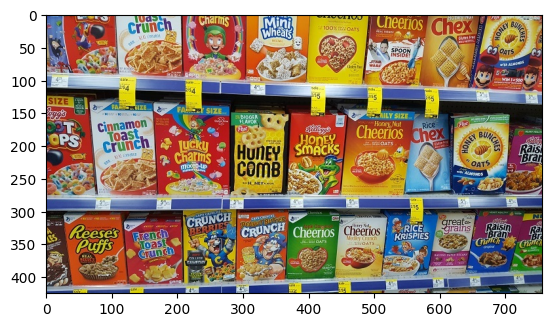

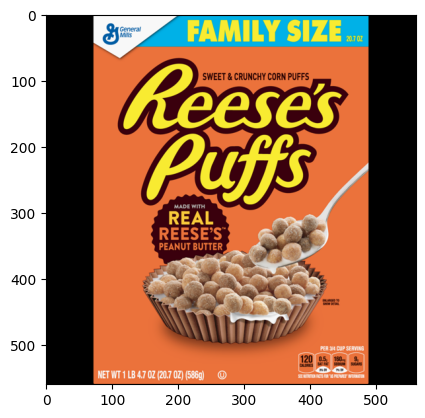

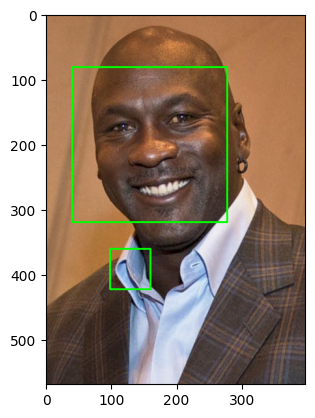

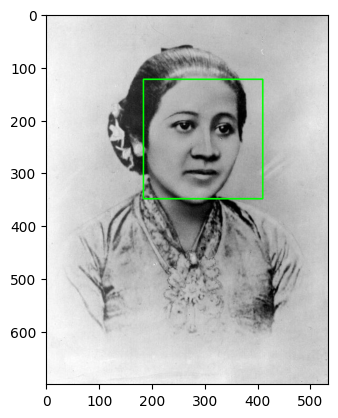

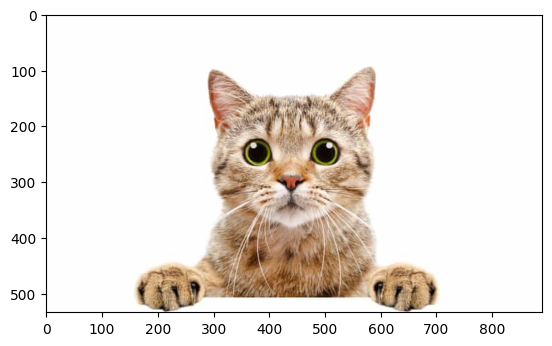

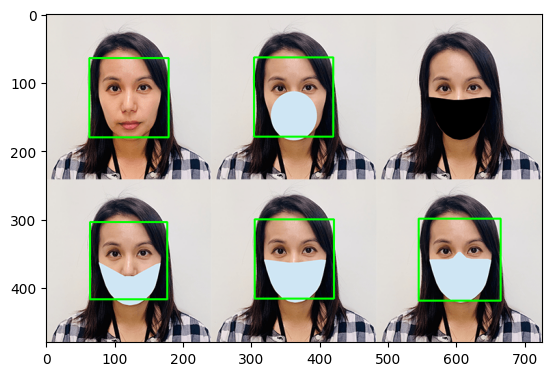

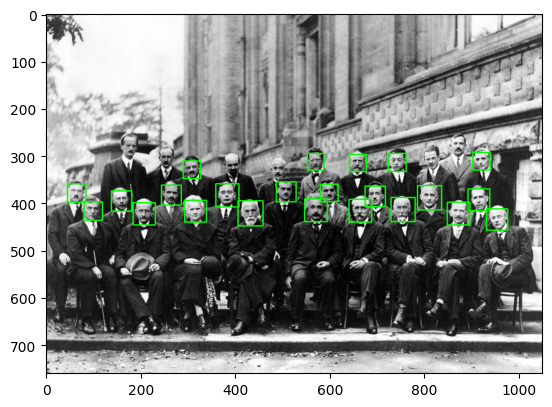

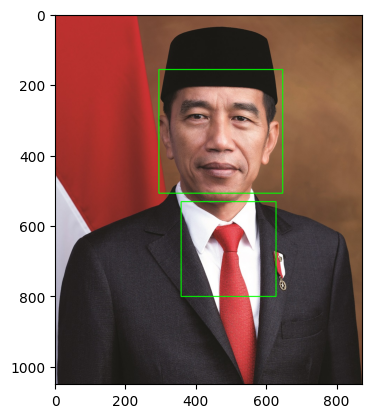

In [21]:
img_dir = Path('/content/drive/MyDrive/pcvk_images/Images/facedet')

files = [f for f in img_dir.iterdir() if f.is_file()]

for file in files:
    img = cv2.imread(str(img_dir / file.name))

    if img is None:
        continue

    # Convert to grayscale (Haar Cascade works on grayscale)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Load pre-trained face detector from OpenCV
    face_cascade = cv2.CascadeClassifier("/content/drive/MyDrive/pcvk_images/Images/haarcascades/haarcascade_frontalface_default.xml")

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,  # controls accuracy/speed tradeoff
        minNeighbors=5,   # higher value = fewer false positives
        minSize=(30, 30)
    )

    # Draw bounding boxes
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)


    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.show()

### 2. Perform Object Detection with Bounding Box to Cat Head

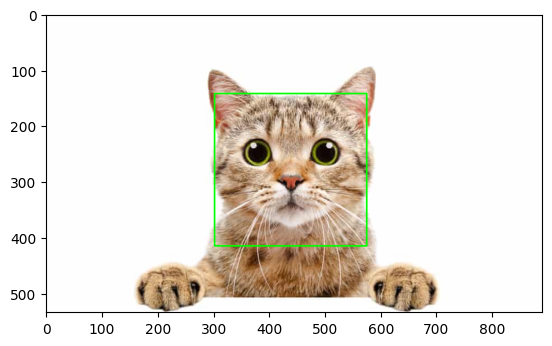

In [22]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/facedet/kucing.jpg')

if img is None:
    raise Exception('File is nout found!')

# Convert to grayscale (Haar Cascade works on grayscale)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load pre-trained face detector from OpenCV
face_cascade = cv2.CascadeClassifier("/content/drive/MyDrive/pcvk_images/Images/haarcascades/haarcascade_frontalcatface.xml")

# Detect faces
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.5,  # controls accuracy/speed tradeoff
    minNeighbors=3,   # higher value = fewer false positives
    minSize=(75, 75)
)

# Draw bounding boxes
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()

### 3. Perform Object Detection with Bounding Box to Eye Object

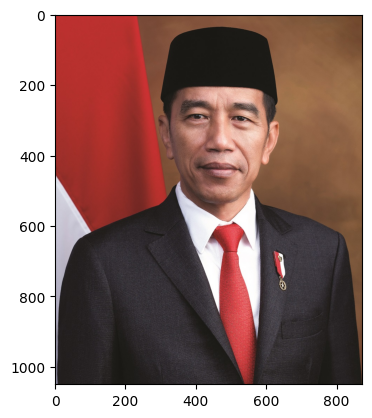

In [23]:
img = cv2.imread(str(img_dir / 'jokowi.jpg'))

if img is None:
    raise Exception('File is nout found!')

# Convert to grayscale (Haar Cascade works on grayscale)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load pre-trained face detector from OpenCV
face_cascade = cv2.CascadeClassifier("/content/drive/MyDrive/pcvk_images/Images/haarcascades/haarcascade_frontalcatface.xml")
eye_cascade = cv2.CascadeClassifier("/content/drive/MyDrive/pcvk_images/Images/haarcascades/haarcascade_eye.xml")

# Detect faces
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.2,  # controls accuracy/speed tradeoff
    minNeighbors=3,   # higher value = fewer false positives
    minSize=(40, 40)
)

# Draw bounding boxes
for (x, y, w, h) in faces:
    # Draw face bounding box
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Focus only on the face region
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

    # Detect eyes within face
    eyes = eye_cascade.detectMultiScale(roi_gray)

    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2)


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()

### 4. Perform Smile Detection On The Image Of People

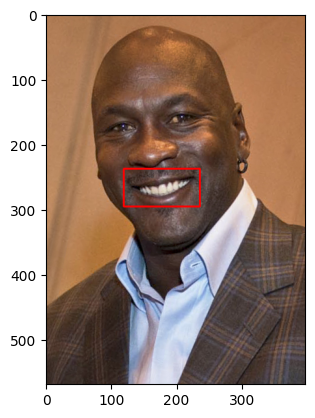

In [24]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/facedet/mjordan.jpg')

if img is None:
    raise Exception("File not found!")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load only smile cascade
smile_cascade = cv2.CascadeClassifier("/content/drive/MyDrive/pcvk_images/Images/haarcascades/haarcascade_smile.xml")

# Detect smiles in the entire image
smiles = smile_cascade.detectMultiScale(
    gray,
    scaleFactor=1.8,
    minNeighbors=22,
    minSize=(25, 25)
)

# Draw bounding boxes for smiles
for (x, y, w, h) in smiles:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)

# Convert to RGB for matplotlib display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()

### 5. Perform Face Tracking

In [25]:
# Load Haar cascade for face detection
face_cascade = cv2.CascadeClassifier("/content/drive/MyDrive/pcvk_images/Images/haarcascades/haarcascade_frontalface_default.xml")

# Start video capture (0 = default camera)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise Exception("Could not open webcam!")

print("Press Ctrl + C to stop the video")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Convert to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        # Draw bounding boxes
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Convert to JPEG for display in notebook
        _, jpeg = cv2.imencode('.jpg', frame)
        img_bytes = jpeg.tobytes()

        # Display inline
        clear_output(wait=True)
        display(IPImage(data=img_bytes))

        time.sleep(0.05)  # small delay for smoother output

except KeyboardInterrupt:
    print("Stopped by user")

cap.release()

Exception: Could not open webcam!

### 6. Apply Blurring To The Detected Face Area

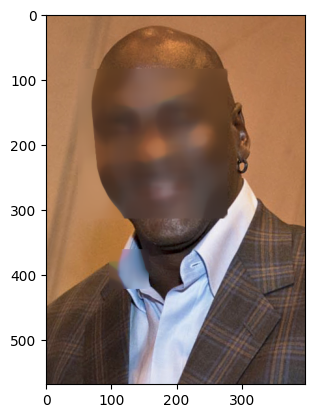

In [7]:
img = cv2.imread('/content/drive/MyDrive/pcvk_images/Images/facedet/mjordan.jpg')

if img is None:
    raise Exception("File not found!")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load Haar cascade for face detection
face_cascade = cv2.CascadeClassifier("/content/drive/MyDrive/pcvk_images/Images/haarcascades/haarcascade_frontalface_default.xml")

# Detect faces
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.3,
    minNeighbors=5,
    minSize=(30, 30)
)

# Apply median blur to detected faces
for (x, y, w, h) in faces:
    face_region = img[y:y+h, x:x+w]

    # Apply median blur — larger kernel = stronger blur
    blurred_face = cv2.medianBlur(face_region, 35)

    # Replace the face region in the original image
    img[y:y+h, x:x+w] = blurred_face

# Convert to RGB for matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()
